In [202]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

X,y = make_blobs(n_samples=1000, centers = 3, n_features = 2)

In [203]:
X

array([[ 7.08893953, 10.86598558],
       [ 1.50878872,  0.68520932],
       [ 7.82002684,  9.18901867],
       ...,
       [ 1.53973362,  0.18570981],
       [ 3.70347481, -0.18814692],
       [ 8.51181598,  5.6374769 ]], shape=(1000, 2))

In [204]:
y

array([0, 1, 0, 0, 2, 2, 0, 2, 1, 2, 2, 0, 0, 2, 2, 0, 2, 1, 2, 1, 0, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2, 0, 0, 0, 0, 2, 1, 0, 2, 0, 2, 0, 0,
       0, 1, 2, 2, 2, 0, 2, 0, 0, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 2, 0, 2,
       1, 2, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 1, 2, 2, 0, 2, 0, 1, 0, 1,
       1, 1, 0, 2, 2, 0, 1, 0, 2, 2, 0, 1, 1, 2, 1, 0, 2, 0, 2, 1, 1, 2,
       1, 1, 0, 0, 1, 2, 2, 0, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 2, 2, 0, 2,
       1, 1, 0, 2, 2, 1, 0, 2, 2, 0, 2, 1, 1, 1, 2, 0, 0, 2, 2, 0, 1, 2,
       2, 1, 0, 0, 2, 0, 0, 0, 1, 2, 2, 0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 2, 0, 1, 1, 1, 0, 0, 2, 1, 1, 1, 2, 0, 0, 2, 0,
       2, 1, 2, 1, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1, 1, 2, 2, 1, 1, 1, 1,
       2, 0, 0, 1, 1, 0, 2, 1, 2, 2, 0, 0, 1, 0, 2, 1, 2, 1, 2, 1, 1, 1,
       0, 0, 1, 2, 2, 0, 2, 0, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 0, 2, 2,
       1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 1, 1, 1, 0, 2, 0,
       2, 1, 2, 2, 1, 0, 2, 2, 1, 1, 0, 2, 1, 1, 0,

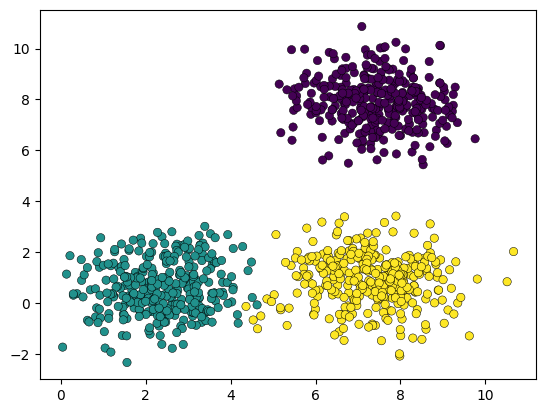

In [215]:
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='black', linewidths=0.35)

In [206]:
from sklearn.preprocessing import StandardScaler 

scalar = StandardScaler()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [207]:
from sklearn.cluster import KMeans


#Elbow Method

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init = 'k-means++')
    kmeans.fit(X_train, X_test)
    wcss.append(kmeans.inertia_)


Text(0, 0.5, 'WCSS')

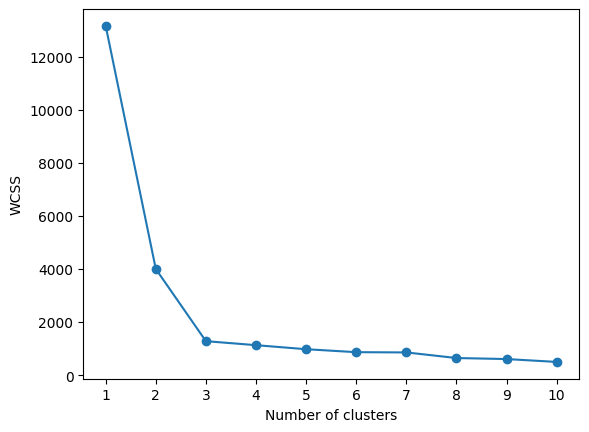

In [208]:
# Plotting the elbow curve

plt.plot(range(1,11), wcss, marker = 'o')
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")

In [209]:
kmeans = KMeans(n_clusters=3, init = 'k-means++')
kmeans.fit_predict(X_train_scaled)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 2, 1, 1, 0, 1, 2, 0, 2, 2, 2, 0, 0, 1,
       2, 1, 1, 2, 1, 0, 0, 0, 2, 1, 2, 0, 1, 1, 2, 2, 0, 2, 0, 0, 2, 2,
       0, 2, 1, 2, 1, 0, 1, 2, 0, 0, 1, 2, 1, 2, 0, 0, 0, 2, 2, 1, 2, 2,
       2, 2, 1, 1, 0, 0, 2, 1, 1, 2, 2, 0, 2, 1, 2, 0, 0, 2, 2, 1, 0, 0,
       1, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 2, 0, 1, 0, 1, 2, 1, 1, 0,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 2, 2, 1, 1, 0, 0, 2, 2, 1, 0, 1, 1, 2,
       2, 1, 1, 1, 2, 1, 2, 1, 0, 2, 0, 1, 1, 2, 0, 1, 1, 0, 1, 1, 0, 2,
       2, 2, 2, 2, 1, 2, 1, 1, 0, 2, 0, 2, 0, 0, 2, 1, 2, 2, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 2, 0, 1, 0, 0, 0, 0, 1,
       2, 2, 1, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 0, 2, 1, 2, 0, 1, 0, 0, 0,
       1, 2, 2, 2, 2, 0, 2, 2, 0, 1, 0, 1, 1, 2, 1, 0, 2, 1, 2, 1, 1, 0,
       2, 2, 1, 1, 0, 0, 1, 1, 2, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 2,
       2, 0, 2, 0, 1, 1, 2, 0, 1, 2, 2, 0, 2, 1, 0, 2, 0, 0, 2, 0, 2, 1,
       0, 0, 1, 0, 2, 1, 1, 2, 2, 2, 0, 2, 1, 1, 0,

In [210]:
y_pred = kmeans.predict(X_test_scaled)

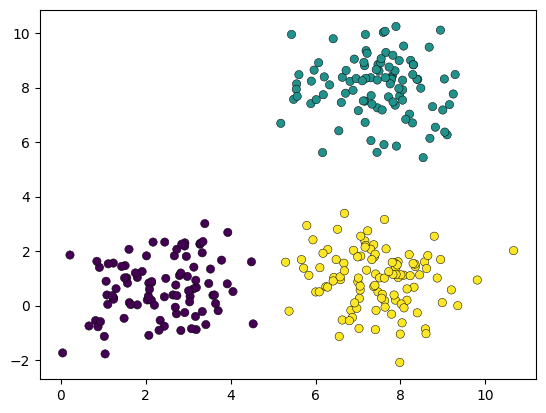

In [214]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred,edgecolors='black', linewidths=0.35)

In [216]:
# Validating the KValues 

# Knee Locator
#Silhoutte Scoring

!pip install kneed

In [218]:
from kneed import KneeLocator

kl = KneeLocator(range(1,11), wcss, curve = 'convex', direction = 'decreasing')
kl.elbow

np.int64(3)

In [223]:
# Sillhoutte Scoring 

from sklearn.metrics import silhouette_score

silhoutte_coefficient = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhoutte_coefficient.append(score)

silhoutte_coefficient


[0.5703544372437594,
 0.6897758681239013,
 0.571998160149037,
 0.48497465899031306,
 0.3668783065719571,
 0.3607076128665653,
 0.3507961240207214,
 0.36083812086424605,
 0.338878990468024]

Text(0, 0.5, 'WCSS')

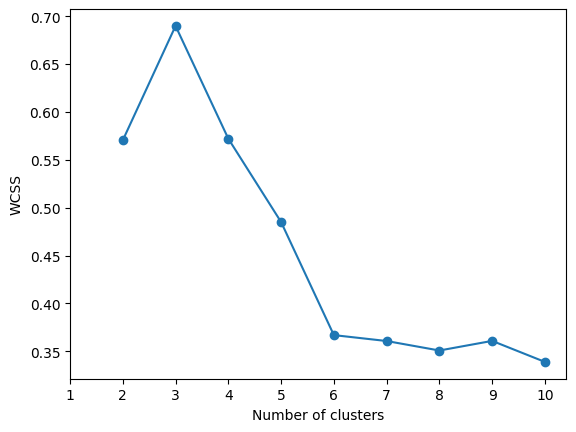

In [228]:
plt.plot(range(2,11), silhoutte_coefficient, marker = 'o',)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")